In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_test.shape

(10000, 32, 32, 3)

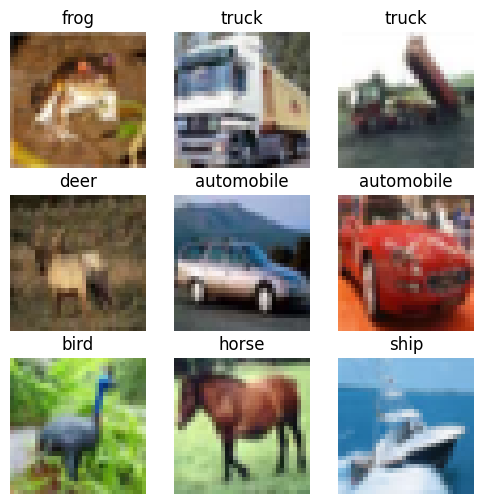

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck']
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
plt.show()

In [ ]:
#Normalization
x_train = x_train / 255.0
x_test = x_test / 255.0


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train, epochs=10, validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4014 - loss: 1.6455 - val_accuracy: 0.5801 - val_loss: 1.1700
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6180 - loss: 1.0873 - val_accuracy: 0.6389 - val_loss: 1.0297
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.6816 - loss: 0.9101 - val_accuracy: 0.6678 - val_loss: 0.9564
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 49ms/step - accuracy: 0.7126 - loss: 0.8281 - val_accuracy: 0.6882 - val_loss: 0.8989
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7451 - loss: 0.7303 - val_accuracy: 0.6917 - val_loss: 0.8933
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7715 - loss: 0.6523 - val_accuracy: 0.6943 - val_loss: 0.9058
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7996 - loss: 0.5844 - val_accuracy: 0.6936 - val_loss: 0.9468
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.8180 -

In [ ]:
# layers.Conv2D(128, (3,3), activation='relu'),
# layers.MaxPooling2D(2,2),


In [ ]:
# layers.Conv2D(32, (5,5), activation='relu')


In [ ]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [ ]:
predictions


array([[7.7122759e-06, 3.7139662e-06, 3.4727840e-04, ..., 6.8033601e-06,
        3.4380516e-03, 1.8857912e-05],
       [2.1616172e-05, 5.5629425e-03, 4.9473203e-09, ..., 1.4921223e-09,
        9.9441415e-01, 1.1556116e-06],
       [1.1568759e-01, 7.7873103e-02, 1.6636656e-04, ..., 6.7147594e-03,
        7.8319579e-01, 1.2102259e-02],
       ...,
       [6.0327894e-09, 2.1431994e-08, 9.6471824e-02, ..., 1.7524530e-04,
        1.0984902e-07, 3.9541611e-08],
       [9.4370407e-01, 3.5938833e-02, 2.5999188e-04, ..., 8.4140374e-06,
        1.4100271e-05, 4.6023612e-05],
       [3.2575258e-08, 1.7574608e-08, 2.5237483e-05, ..., 9.9839801e-01,
        6.0318532e-09, 3.2131192e-07]], dtype=float32)

In [ ]:
y_pred = np.argmax(predictions, axis=1)

In [ ]:
y_true = y_test.flatten()

In [ ]:
wrong_indices = np.where(y_pred != y_true)[0]
print('Total wrong predictions', len(wrong_indices))

Total wrong predictions 3074


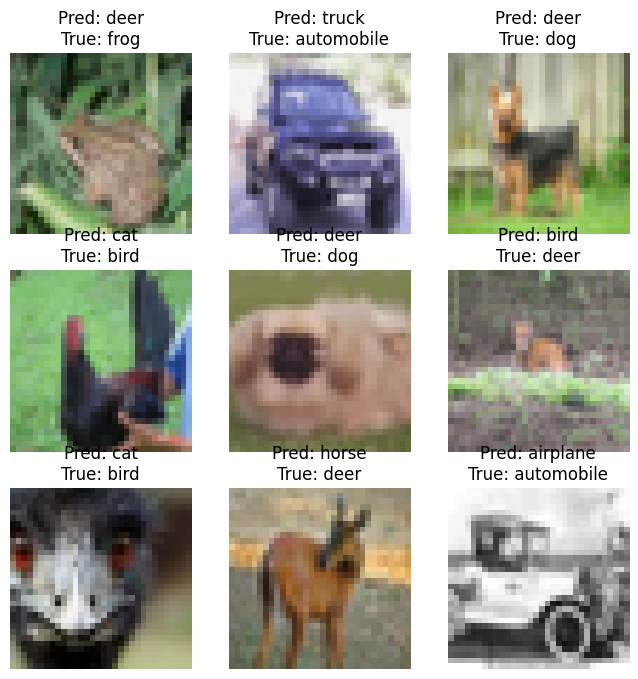

In [ ]:
plt.figure(figsize=(8,8))
for i, idx in enumerate(wrong_indices[:9]):
  plt.subplot(3,3,i+1)
  plt.imshow(x_test[idx])
  plt.title(
      f'Pred: {class_names[y_pred[idx]]}\n'
      f'True: {class_names[y_true[idx]]}'
  )
  plt.axis('off')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

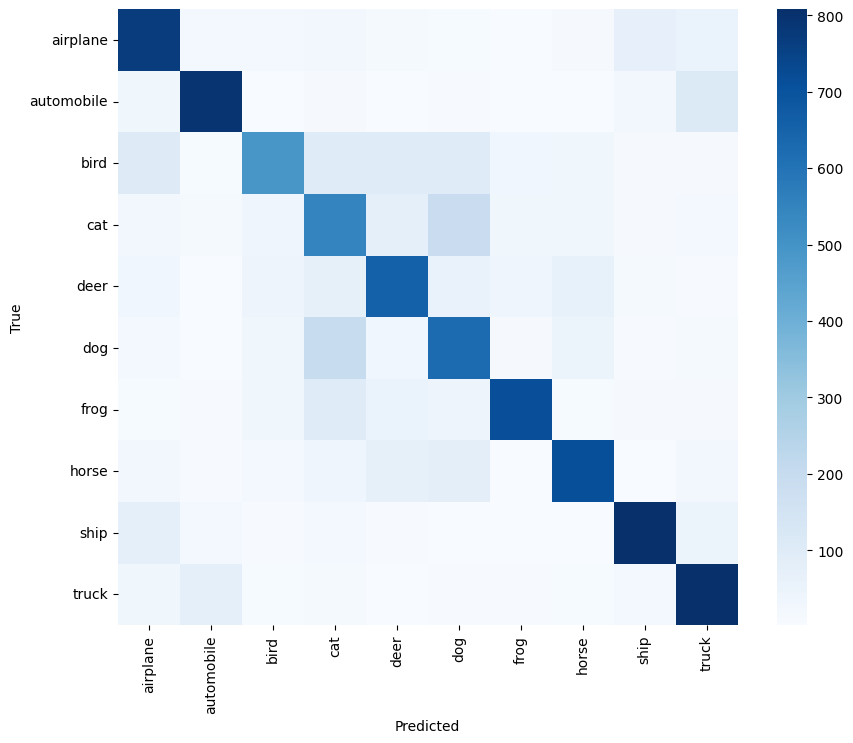

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
#Data Augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
datagen.fit(x_train)
history_aug = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.6588 - loss: 1.0042 - val_accuracy: 0.7009 - val_loss: 0.8911
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.6839 - loss: 0.9029 - val_accuracy: 0.7209 - val_loss: 0.8233
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 122ms/step - accuracy: 0.6954 - loss: 0.8779 - val_accuracy: 0.7267 - val_loss: 0.8102
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.7017 - loss: 0.8519 - val_accuracy: 0.7269 - val_loss: 0.8000
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.7124 - loss: 0.8293 - val_accuracy: 0.7356 - val_loss: 0.7927
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.7160 - loss: 0.7978 - val_accuracy: 0.7192 - val_loss: 0.8402
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 117ms/step - accuracy: 0.7187 - loss: 0.8020 - val_accuracy: 0.7360 - val_loss: 0.7831
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.7221 - loss: 0.7913 - va

In [ ]:
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()
wrong_indices = np.where(y_pred != y_true)[0]
print('Total wrong predictions', len(wrong_indices))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Total wrong predictions 2573


In [ ]:
#TRANSFER LEARNING
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

/tmp/ipython-input-1595730597.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable=False

In [ ]:
transfer_model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])